# Task 2

In this task you will implement a multi-layer perceptron (MLP) for classification, the
finite-differences approach for approximately computing the gradient of the loss with
respect to the weights of the MLP, and train the MLP using the Adam optimizer (which
is a variant of SGD that uses individual learning rates for each parameter).

In [1]:
import h5py
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from _stochastic_optimizers import AdamOptimizer
import time
import matplotlib.pyplot as plt

## Subtask 1: Classification Data

In [3]:
hf = h5py.File('D:/My_ML/UniWien/intro_to_ML/data/classification.h5', 'r')
x_train = np.array(hf.get('x_train'))
y_train = np.array(hf.get('y_train'))
x_test = np.array(hf.get('x_test'))
y_test = np.array(hf.get('y_test'))
hf.close()


In [4]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Dataset statistics**

In [5]:
print("1 Feature STATISTICS")
print(f"   Number of features: {x_train.shape[1]}")
print(f"   Training samples: {x_train.shape[0]}")
print(f"   Test samples: {x_test.shape[0]}")
print(f"   Total samples: {x_train.shape[0] + x_test.shape[0]}")   
print("2 TARGET STATISTICS")
print(f"   Unique values in y_train: {np.unique(y_train.shape[0])}")
print(f"   Unique values in y_test: {np.unique(y_test.shape[0])}")
print("3 CLASS DISTRIBUTION")
print(f"   Training set: {y_train.shape[0]} samples with {y_train.shape[1]} classes each")
print(f"   Test set: {y_test.shape[0]} samples with {y_test.shape[1]} classes each")

1 Feature STATISTICS
   Number of features: 2
   Training samples: 500
   Test samples: 10000
   Total samples: 10500
2 TARGET STATISTICS
   Unique values in y_train: [500]
   Unique values in y_test: [10000]
3 CLASS DISTRIBUTION
   Training set: 500 samples with 1 classes each
   Test set: 10000 samples with 1 classes each


## Subtask 2: Forward Propagation

In [6]:
class CustomMLP:
    def __init__(self, layer_sizes, activation='relu', seed=42):
        """
        Init of the MLP
        Parameters:
        layer_sizes : list
            List of layers size [input_size, hidden1_size, ..., output_size]
        activation : str
           Activation function ('relu', 'sigmoid', 'tanh')
        """
        self.layer_sizes = layer_sizes
        self.activation_name = activation
        self.weights = []
        self.biases = []
        
        # Initialization of weights and biases
        np.random.seed(seed)
        for i in range(len(layer_sizes) - 1):
            scale = np.sqrt(2.0 / (layer_sizes[i] + layer_sizes[i+1]))
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * scale
            b = np.zeros((1, layer_sizes[i+1]))
        
            self.weights.append(W)
            self.biases.append(b)
    
    def _activation(self, x):
        if self.activation_name == 'relu':
            return np.maximum(0, x)
        elif self.activation_name == 'sigmoid':
            return 1 / (1 + np.exp(-x))
        elif self.activation_name == 'tanh':
            return np.tanh(x)
    
    def forward(self, x):
        if len(x.shape) == 1:
            x = x.reshape(1, -1)
        
        outputs = [x]
        current = x
        for i in range(len(self.weights) - 1):
            z = np.dot(current, self.weights[i]) + self.biases[i]
            a = self._activation(z)
            outputs.append(z)  # linear output
            outputs.append(a)  # output after activation
            current = a
        # Output layer without activation
        z_final = np.dot(current, self.weights[-1]) + self.biases[-1]
        outputs.append(z_final)
        
        return outputs
    
    def predict(self, x):
        #Prediction for input data
        outputs = self.forward(x)
        return outputs[-1]
    
    def get_parameters(self):
        # Get all model parametrs as list
        params = []
        for W, b in zip(self.weights, self.biases):
            params.append(W.flatten())
            params.append(b.flatten())
        return np.concatenate(params)
    
    def set_parameters(self, flat_params):
        #Set model parametrs from a list
        idx = 0
        for i in range(len(self.weights)):
            W_size = self.weights[i].size
            b_size = self.biases[i].size
            self.weights[i] = flat_params[idx:idx+W_size].reshape(self.weights[i].shape)
            idx += W_size
            self.biases[i] = flat_params[idx:idx+b_size].reshape(self.biases[i].shape)
            idx += b_size

In this implemetation the class CustomMLP consist of several functions. The init() function initializez the weights matrix W (using random Glorot (tanh) initialization) and the biases vector b as zeros.
Then activation functions Relu, Sigmoid and Tanh are defined via numpy mathematical functions. After that forward propagation is implemented according to lecture slides.
The weigths and biases are stored as Class attributes as arrays.

## Subtask 3: Finite Difference Gradient & Optimization

In [11]:
def hinge_loss(predictions, targets):
    # Hinge loss function for classification task

    # Resccaling targets {-1, 1}
    y_binary = 2 * targets - 1  # targets ∈ {0, 1}
    y_binary = y_binary.reshape(-1, 1)
    
    # Hinge loss
    loss = np.maximum(0, 1 - y_binary * predictions)
    return np.mean(loss)

def finite_difference_gradient(model, x, y, epsilon=1e-5):
    # Gradient calculation with finite defferences method
    # Save the original params
    original_params = model.get_parameters()
    
    # Initialize lists for the gradients
    grad_weights = [np.zeros_like(W) for W in model.weights]
    grad_biases = [np.zeros_like(b) for b in model.biases]
    
    # Calculating the original loss function
    pred_original = model.predict(x)
    loss_original = hinge_loss(pred_original, y)
    
    # Calculating the gradients for each patametr 
    param_idx = 0
    for layer_idx in range(len(model.weights)):
        # Gradient on weights
        W = model.weights[layer_idx]
        for i in range(W.shape[0]):
            for j in range(W.shape[1]):
                # Recover the orinila params
                model.set_parameters(original_params)
                # W + epsilon
                model.weights[layer_idx][i, j] += epsilon
                pred_plus = model.predict(x)
                loss_plus = hinge_loss(pred_plus, y)
                # W - epsilon
                model.set_parameters(original_params)
                model.weights[layer_idx][i, j] -= epsilon
                pred_minus = model.predict(x)
                loss_minus = hinge_loss(pred_minus, y)
                # Gradient approximation
                grad_weights[layer_idx][i, j] = (loss_plus - loss_minus) / (2 * epsilon)
        
        # Gradient for biases
        b = model.biases[layer_idx]
        for i in range(b.shape[1]):
            # Recover of original params
            model.set_parameters(original_params)
            # b + epsilon
            model.biases[layer_idx][0, i] += epsilon
            pred_plus = model.predict(x)
            loss_plus = hinge_loss(pred_plus, y)
            # b - epsilon
            model.set_parameters(original_params)
            model.biases[layer_idx][0, i] -= epsilon
            pred_minus = model.predict(x)
            loss_minus = hinge_loss(pred_minus, y)
            # Gradient approximation
            grad_biases[layer_idx][0, i] = (loss_plus - loss_minus) / (2 * epsilon)
    # Recover of original params
    model.set_parameters(original_params)
    return grad_weights, grad_biases

def train_with_finite_differences(x_train, y_train, x_test, y_test, layer_sizes, activation='relu', epochs=100, lr=0.001, batch_size=32):
    # Model training using finite_difference_gradient
    model = CustomMLP(layer_sizes, activation=activation)
    #initializing the Adam optimizer
    all_params = []
    for i in range(len(model.weights)):
        all_params.append(model.weights[i])   # weights
        all_params.append(model.biases[i])
    optimizer = AdamOptimizer(all_params, lr, 0.9, 0.999, 1e-08)

    # For history of training
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    n_samples = x_train.shape[0]
    
    print(f"Training MLP with architecture: {layer_sizes}, activation: {activation}")
    start_time = time.time()
    
    for epoch in range(epochs):
        # Data permutation
        indices = np.random.permutation(n_samples)
        x_train_shuffled = x_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_loss = 0
        n_batches = 0
        
        for i in range(0, n_samples, batch_size):
            batch_end = min(i + batch_size, n_samples)
            x_batch = x_train_shuffled[i:batch_end]
            y_batch = y_train_shuffled[i:batch_end]
            
            # Gradient calculations
            grad_weights, grad_biases = finite_difference_gradient(model, x_batch, y_batch)
            all_grads = []
            for j in range(len(grad_weights)):
                all_grads.append(grad_weights[j])   # градиенты по весам
                all_grads.append(grad_biases[j])    # градиенты по смещениям
            
            # ОБНОВЛЯЕМ: передаем all_params и all_grads в правильном порядке
            optimizer.update_params(all_params, all_grads)
            
            # После обновления оптимизатором, обновляем параметры в модели
            for j in range(len(model.weights)):
                model.weights[j] = all_params[2*j].copy()
                model.biases[j] = all_params[2*j + 1].copy()
            
            # Loss calc
            pred_batch = model.predict(x_batch)
            batch_loss = hinge_loss(pred_batch, y_batch)
            epoch_loss += batch_loss
            n_batches += 1
        
        # Avarage loss in epoch
        avg_train_loss = epoch_loss / n_batches if n_batches > 0 else 0
        
        # Make predictions
        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)
        
        train_loss = hinge_loss(train_pred, y_train)
        test_loss = hinge_loss(test_pred, y_test)
        
        # Accuracy calculation
        train_acc = np.mean((train_pred > 0).astype(int).flatten() == y_train)
        test_acc = np.mean((test_pred > 0).astype(int).flatten() == y_test)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}, "
                  f"Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")
    
    return model, train_losses, test_losses, train_accs, test_accs, training_time


--- Architecture 1: [input, 10, 10, 1] with ReLU ---
Training MLP with architecture: [2, 10, 10, 1], activation: relu
Epoch 0: Train Loss = 0.9196, Test Loss = 0.9575, Train Acc = 0.5120, Test Acc = 0.5158
Epoch 10: Train Loss = 0.8303, Test Loss = 0.9026, Train Acc = 0.5014, Test Acc = 0.5023
Epoch 20: Train Loss = 0.7633, Test Loss = 0.8747, Train Acc = 0.5006, Test Acc = 0.5010
Epoch 30: Train Loss = 0.7557, Test Loss = 0.8714, Train Acc = 0.5007, Test Acc = 0.5011
Epoch 40: Train Loss = 0.7524, Test Loss = 0.8674, Train Acc = 0.5003, Test Acc = 0.5004
Training completed in 52.11 seconds

--- Architecture 2: [input, 20, 10, 1] with Sigmoid ---
Training MLP with architecture: [2, 20, 10, 1], activation: sigmoid
Epoch 0: Train Loss = 1.0125, Test Loss = 1.0098, Train Acc = 0.4903, Test Acc = 0.4868
Epoch 10: Train Loss = 0.9172, Test Loss = 0.9439, Train Acc = 0.5045, Test Acc = 0.5065
Epoch 20: Train Loss = 0.7667, Test Loss = 0.8594, Train Acc = 0.5023, Test Acc = 0.5036
Epoch 30: 

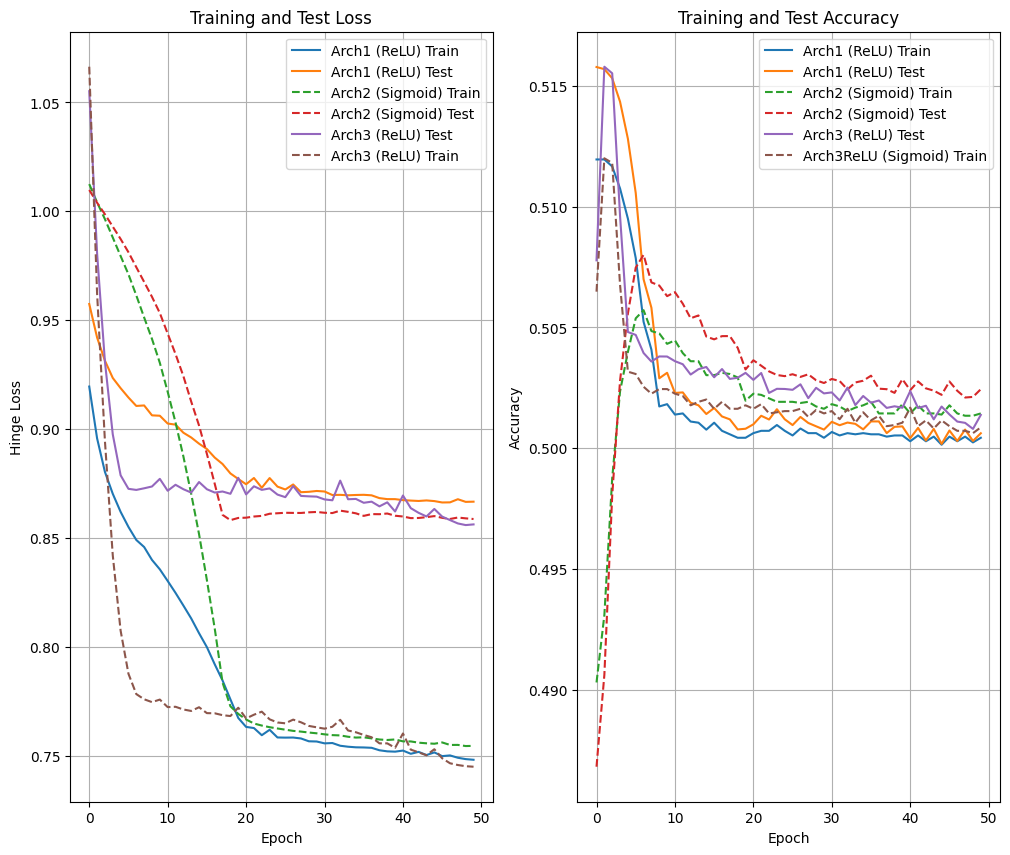

In [ ]:
input_size = x_train.shape[1]
arch1_layer_sizes = [input_size, 10, 10, 1] 
print("\n--- Architecture 1: [input, 10, 10, 1] with ReLU ---")
model1, train_loss1, test_loss1, train_acc1, test_acc1, time1 = train_with_finite_differences(
    x_train, y_train, x_test, y_test,
    layer_sizes=arch1_layer_sizes, activation='relu',
    epochs=50, lr=0.001, batch_size=32)
    
arch2_layer_sizes = [input_size, 20, 10, 1]
print("\n--- Architecture 2: [input, 20, 10, 1] with Sigmoid ---")
model2, train_loss2, test_loss2, train_acc2, test_acc2, time2 = train_with_finite_differences(
    x_train, y_train, x_test, y_test,
        layer_sizes=arch2_layer_sizes, activation='sigmoid',
        epochs=50, lr=0.001, batch_size=32)

arch3_layer_sizes = [input_size, 30, 15, 1]
print("\n--- Architecture 3: [input, 30, 15, 1] with ReLU ---")
model3, train_loss3, test_loss3, train_acc3, test_acc3, time3 = train_with_finite_differences(
    x_train, y_train, x_test, y_test,
        layer_sizes=arch2_layer_sizes, activation='relu',
        epochs=50, lr=0.001, batch_size=32)
    
# Result visualization
fig, axes = plt.subplots(1, 2, figsize=(8, 10))
    
axes[0].plot(train_loss1, label='Arch1 (ReLU) Train')
axes[0].plot(test_loss1, label='Arch1 (ReLU) Test')
axes[0].plot(train_loss2, label='Arch2 (Sigmoid) Train', linestyle='--')
axes[0].plot(test_loss2, label='Arch2 (Sigmoid) Test', linestyle='--')
axes[0].plot(test_loss3, label='Arch3 (ReLU) Test')
axes[0].plot(train_loss3, label='Arch3 (ReLU) Train', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Hinge Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(train_acc1, label='Arch1 (ReLU) Train')
axes[1].plot(test_acc1, label='Arch1 (ReLU) Test')
axes[1].plot(train_acc2, label='Arch2 (Sigmoid) Train', linestyle='--')
axes[1].plot(test_acc2, label='Arch2 (Sigmoid) Test', linestyle='--')
axes[1].plot(test_acc3, label='Arch3 (ReLU) Test')
axes[1].plot(train_acc3, label='Arch3ReLU (Sigmoid) Train', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True)

## Subtask 4: Model training using PyTorch